In [1]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor

from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression,Lasso,Ridge

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [3]:
df=pd.read_csv('stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


independent features and dependant features

In [5]:
X=df.drop(columns=['math_score'],axis=1)
y=df['math_score']

create acolumn transformer with 3 types of transformers


In [6]:
num_features=X.select_dtypes(exclude="object").columns
cat_features=X.select_dtypes(include="object").columns

In [7]:
num_features

Index(['reading_score', 'writing_score'], dtype='object')

In [8]:
cat_features

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

In [9]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [10]:
numeric_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

In [11]:
preprocessor=ColumnTransformer(
    [
        ("oneHotEncoder",cat_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ]
) 

In [12]:
X=preprocessor.fit_transform(X)

In [13]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [14]:
X.shape

(1000, 19)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

creating a function for evaluation metrics 

In [17]:
from sklearn.metrics import root_mean_squared_error

In [20]:
def evaluateModel(true,predicted):
    mae=mean_absolute_error(true,predicted)
    # mse=mean_squared_error(true,predicted)
    rmse=root_mean_squared_error(true,predicted)
    r2_square=r2_score(true,predicted)

    return mae,rmse,r2_square

In [21]:
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor()
}

In [29]:
model_list=[]
r2_list=[]


for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluateModel(y_train, y_train_pred)    

    model_test_mae,model_test_rmse,model_test_r2=evaluateModel(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    r2_list.append(model_test_r2)


    print("\nTraining Performance")
    print(f"MAE      : {model_train_mae:.4f}")
    print(f"RMSE     : {model_train_rmse:.4f}")
    print(f"R2 Score : {model_train_r2:.4f}")

    print("\nTesting Performance")
    print(f"MAE      : {model_test_mae:.4f}")
    print(f"RMSE     : {model_test_rmse:.4f}")
    print(f"R2 Score : {model_test_r2:.4f}")

    print('='*35)
    print('\n')

LinearRegression

Training Performance
MAE      : 4.2667
RMSE     : 5.3231
R2 Score : 0.8743

Testing Performance
MAE      : 4.2148
RMSE     : 5.3940
R2 Score : 0.8804


Lasso

Training Performance
MAE      : 5.2063
RMSE     : 6.5938
R2 Score : 0.8071

Testing Performance
MAE      : 5.1579
RMSE     : 6.5197
R2 Score : 0.8253


Ridge

Training Performance
MAE      : 4.2650
RMSE     : 5.3233
R2 Score : 0.8743

Testing Performance
MAE      : 4.2111
RMSE     : 5.3904
R2 Score : 0.8806


K-Neighbors Regressor

Training Performance
MAE      : 4.5270
RMSE     : 5.7172
R2 Score : 0.8550

Testing Performance
MAE      : 5.6280
RMSE     : 7.2553
R2 Score : 0.7837


Decision Tree

Training Performance
MAE      : 0.0187
RMSE     : 0.2795
R2 Score : 0.9997

Testing Performance
MAE      : 5.9700
RMSE     : 7.5166
R2 Score : 0.7678


RandomForestRegressor

Training Performance
MAE      : 1.8237
RMSE     : 2.2721
R2 Score : 0.9771

Testing Performance
MAE      : 4.6772
RMSE     : 6.0302
R2 Score : 0.85

In [30]:
results = pd.DataFrame({
    "Model": model_list,
    "R2 Score": r2_list
})

In [31]:
results = results.sort_values(by="R2 Score", ascending=False)

In [32]:
results

,Model,R2 Score
2,Ridge,0.880593
0,LinearRegression,0.880433
7,AdaBoostRegressor,0.853259
5,RandomForestRegressor,0.850564
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783681
4,Decision Tree,0.767813


lINEAR REGRESSION

In [34]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)

y_pred=lin_model.predict(X_test)

score=r2_score(y_test,y_pred)

In [35]:
score

0.8804332983749564

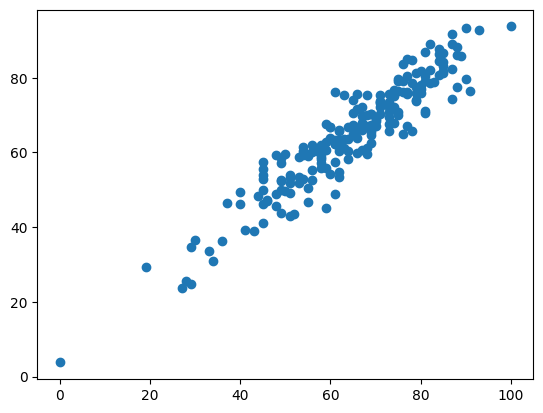

In [36]:
plt.scatter(y_test,y_pred)

<Axes: xlabel='math_score'>

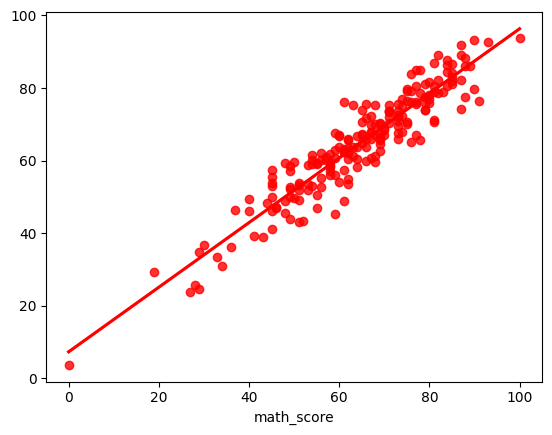

In [37]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')